In [2]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
from starcat import starCAT
import matplotlib.pyplot as plt
import seaborn as sns


/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/sibcb1/bioinformatics/yangyue/minicon

In [3]:

# ===========================
# 0. 全局参数设置
# ===========================
WORK_DIR = "./5.4.Aging/"
ADATA_PATH = "/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/5.5_startCAT_Aging/GSE157007_scRNA_anno.h5ad"

#GEP_ANNO_PATH = "../../3.cGEP_topgene/3.3.CD8T_cGEP_Anno_Complete_With_Genes.csv"

# 设置绘图参数
sc.settings.verbosity = 3
sc.set_figure_params(dpi=300, facecolor='white', vector_friendly=True)

# 切换目录
if not os.path.exists(WORK_DIR):
    os.makedirs(WORK_DIR)
os.chdir(WORK_DIR)
print(f"当前工作目录: {os.getcwd()}")

# ===========================
# 1. 读取数据并筛选 CD8T
# ===========================
print(">>> 正在读取数据...")
adata = sc.read_h5ad(ADATA_PATH)
adata

当前工作目录: /sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/5.disease/5.4.Aging
>>> 正在读取数据...


AnnData object with n_obs × n_vars = 128291 × 20920
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'group', 'age', 'percent.mt', 'RNA_snn_res.0.4', 'seurat_clusters', 'seurat_clusters_backup', 'cell_type', 'celltype', 'barcode'
    obsm: 'X_integrated.cca', 'X_pca', 'X_umap'

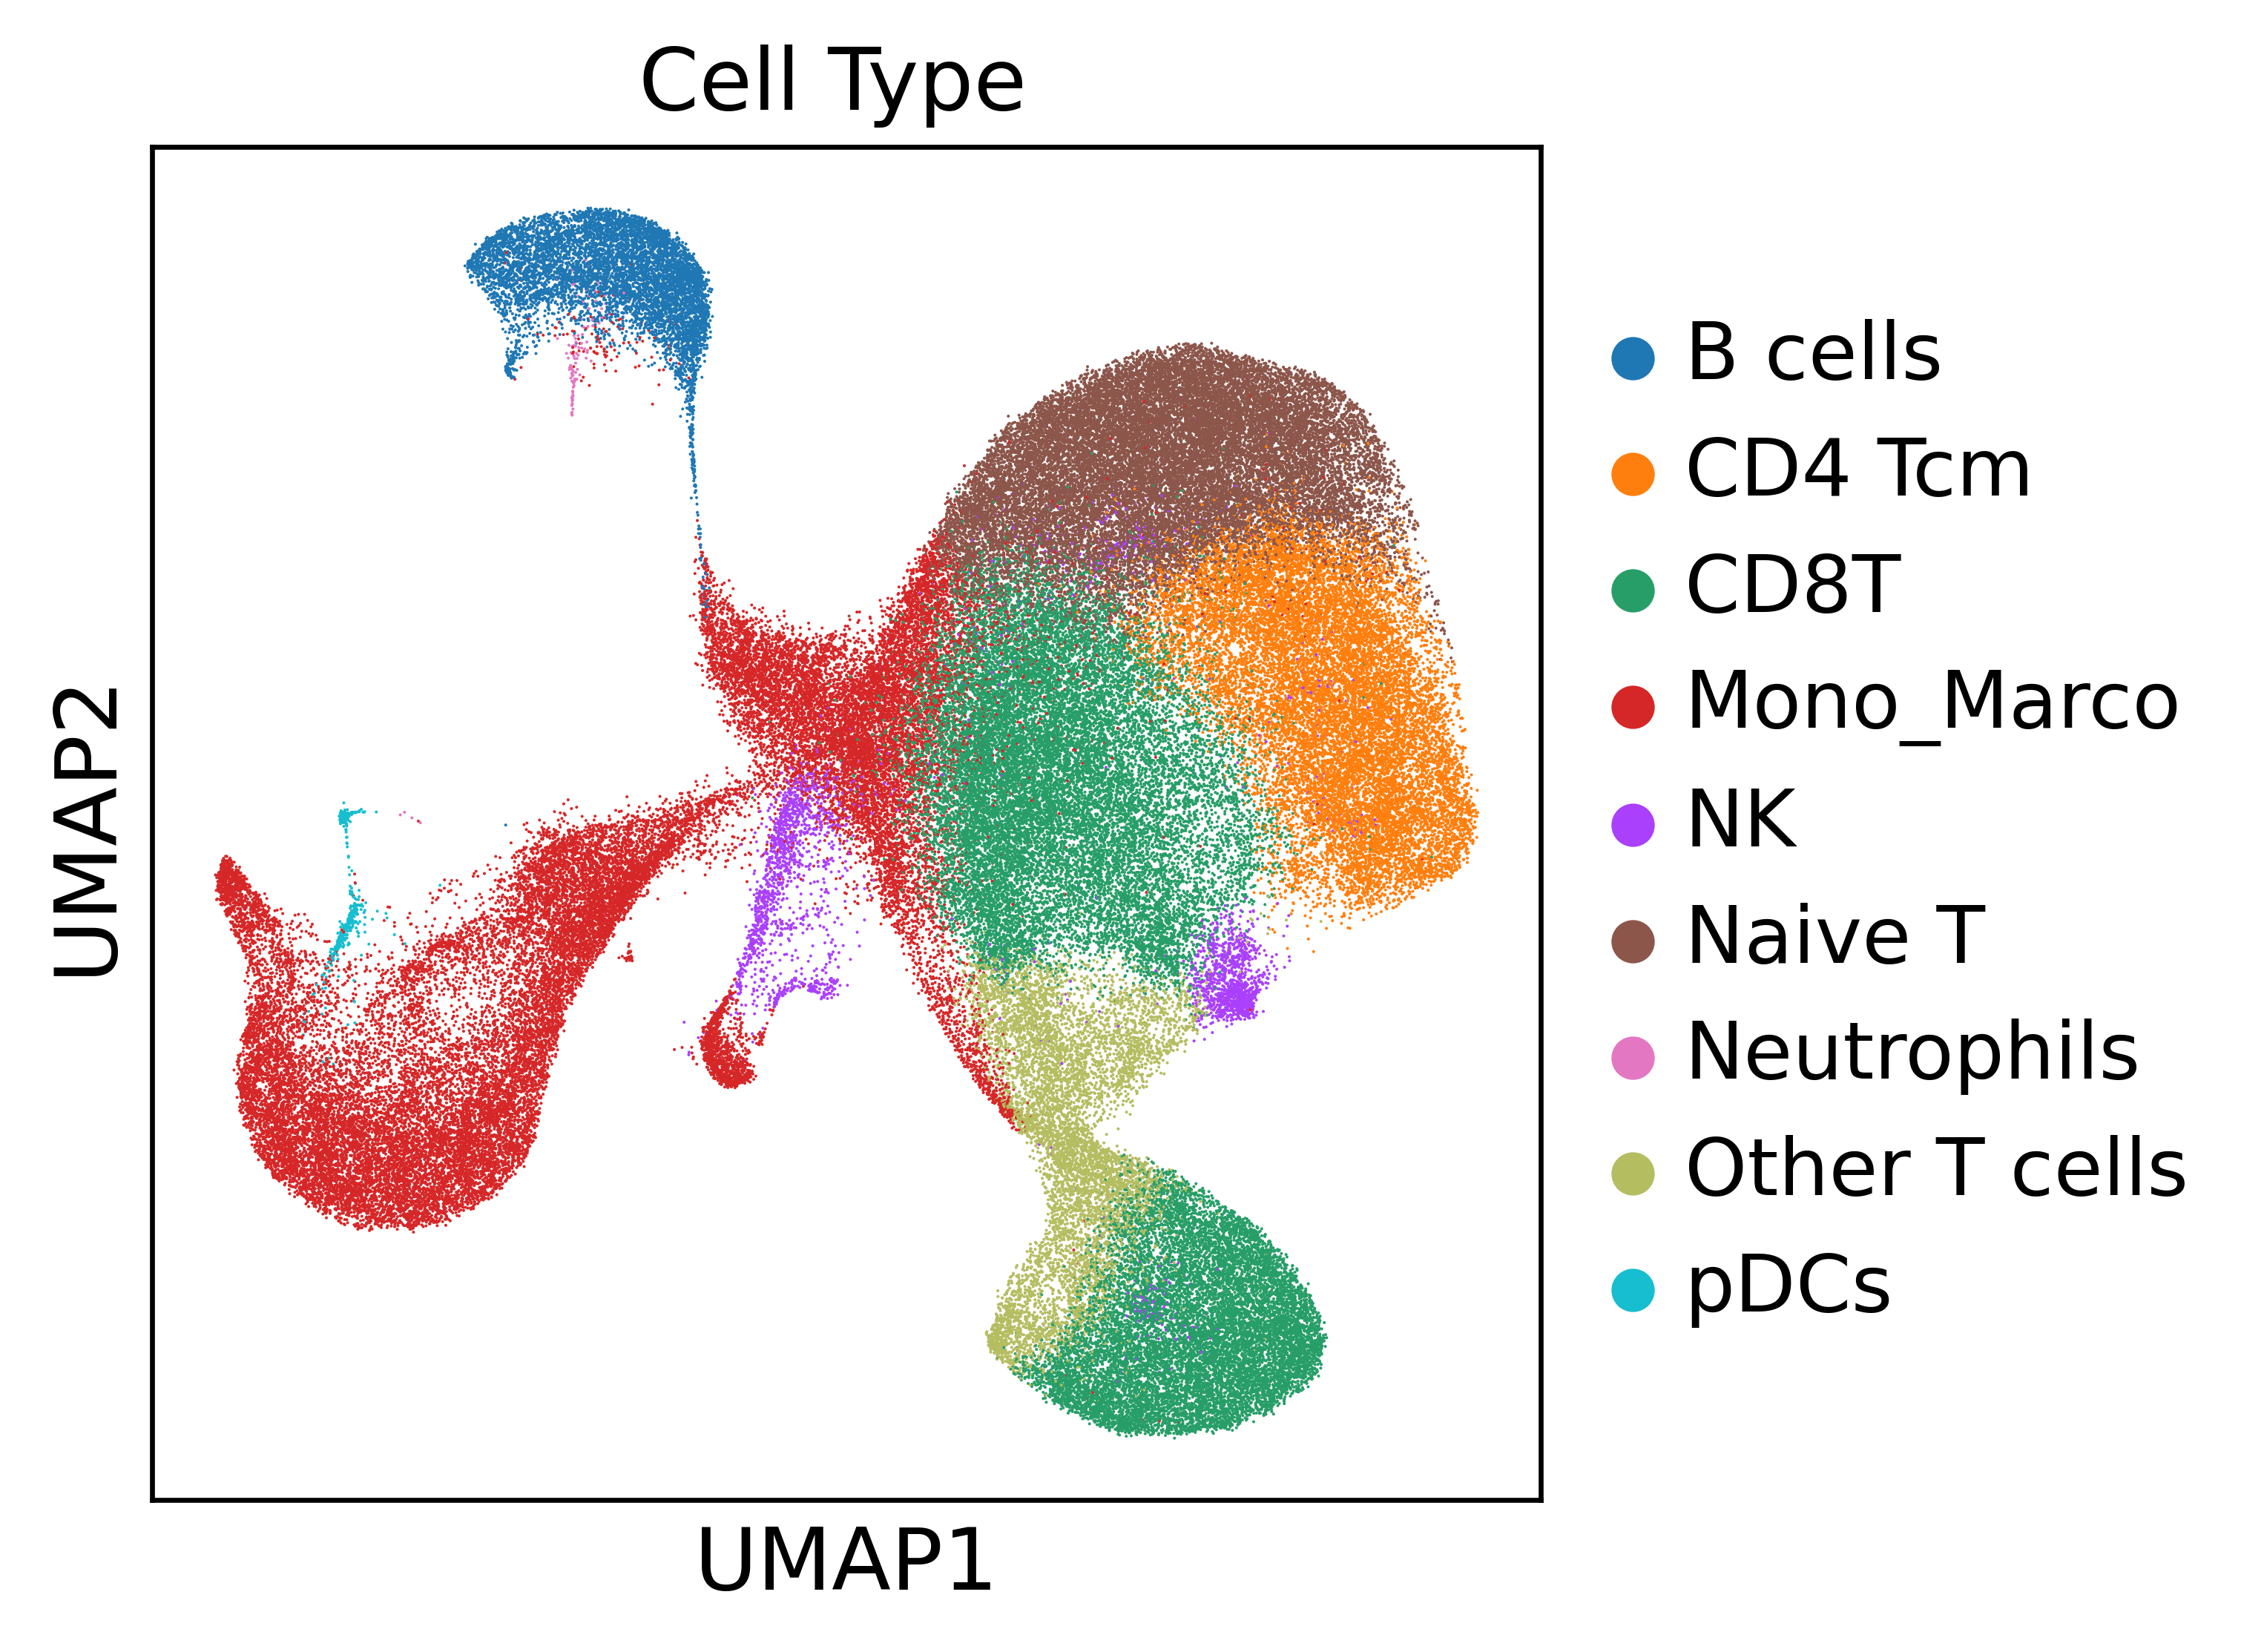

In [4]:
sc.pl.umap(adata, color='celltype', title='Cell Type ')

In [5]:

# 筛选 Neutrophils 细胞
query_adata = adata[adata.obs["celltype"] == "Neutrophils"].copy()
print(f"Neutrophils 细胞数量: {query_adata.n_obs}")

query_adata

Neutrophils 细胞数量: 116


AnnData object with n_obs × n_vars = 116 × 20920
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'group', 'age', 'percent.mt', 'RNA_snn_res.0.4', 'seurat_clusters', 'seurat_clusters_backup', 'cell_type', 'celltype', 'barcode'
    uns: 'celltype_colors'
    obsm: 'X_integrated.cca', 'X_pca', 'X_umap'